In [1]:
# ============================================================
# 셀 1 - 라이브러리 임포트 및 경로 설정
# CLIP 기반 deepfake 탐지 모델로 이미지/영상을 판별합니다.
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from pathlib import Path
from torchvision import transforms
from transformers import CLIPModel
from PIL import Image

BASE_DIR  = Path(r"C:\Users\user\Desktop\deepfake-detector")
MODEL_DIR = BASE_DIR / "models" / "clip_lndf"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ============================================================
# 셀 2 - 모델 구조 정의 및 best_model.pth 로드
# 15_train_clip.ipynb와 동일한 구조입니다.
# ============================================================

class CLIPLayerNormDetector(nn.Module):
    def __init__(self):
        super().__init__()
        clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.vision_encoder = clip.vision_model
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
        for name, module in self.vision_encoder.named_modules():
            if isinstance(module, nn.LayerNorm):
                for param in module.parameters():
                    param.requires_grad = True
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        outputs = self.vision_encoder(pixel_values=x)
        cls_token = outputs.last_hidden_state[:, 0, :]
        cls_token = nn.functional.normalize(cls_token, p=2, dim=1)
        logits = self.classifier(cls_token)
        return logits

model = CLIPLayerNormDetector()
model.load_state_dict(torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("모델 로드 완료")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료


In [3]:
# ============================================================
# 셀 3 - 전처리 및 inference 함수 정의
# predict_image: 이미지 한 장 판별
# predict_video: 영상에서 프레임 샘플링 후 판별
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    ),
])


def predict_image(image_path, verbose=True):
    """이미지 한 장 real/fake 판별"""
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
        fake_prob = probs[0][1].item()
        pred = "FAKE" if fake_prob > 0.5 else "REAL"

    if verbose:
        print(f"경로: {image_path}")
        print(f"FAKE 확률: {fake_prob*100:.2f}%")
        print(f"판별 결과: {pred}")
    return {"result": pred, "fake_prob": fake_prob}


def predict_video(video_path, sample_frames=32, visualize=True):
    """영상에서 프레임 샘플링 후 real/fake 판별"""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"영상을 열 수 없습니다: {video_path}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps if fps > 0 else 0

    indices = np.linspace(0, total_frames - 1, sample_frames, dtype=int)
    frames, fake_probs = [], []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame_rgb)
        tensor = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = model(tensor)
            probs = torch.softmax(logits, dim=1)
            fake_prob = probs[0][1].item()

        frames.append(frame_rgb)
        fake_probs.append(fake_prob)

    cap.release()

    fake_probs = np.array(fake_probs)
    mean_fake_prob = fake_probs.mean()
    fake_frame_ratio = (fake_probs > 0.5).mean() * 100
    result = "FAKE" if mean_fake_prob > 0.5 else "REAL"

    print(f"\n경로: {video_path}")
    print(f"총 프레임: {total_frames} | FPS: {fps:.1f} | 길이: {duration:.1f}초")
    print(f"샘플 프레임: {len(fake_probs)}장")
    print(f"평균 FAKE 확률: {mean_fake_prob*100:.2f}%")
    print(f"FAKE 판정 프레임 비율: {fake_frame_ratio:.1f}%")
    print(f"최종 판별: {result}")

    if visualize:
        _visualize_video_result(frames, fake_probs, result, mean_fake_prob, video_path)

    return {
        "result": result,
        "mean_fake_prob": mean_fake_prob,
        "fake_frame_ratio": fake_frame_ratio,
        "fake_probs": fake_probs.tolist(),
    }


def _visualize_video_result(frames, fake_probs, result, mean_fake_prob, video_path):
    n = min(8, len(frames))
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))
    color = "red" if result == "FAKE" else "green"

    for i in range(n):
        axes[0, i].imshow(frames[i])
        axes[0, i].axis("off")
        frame_result = "F" if fake_probs[i] > 0.5 else "R"
        frame_color  = "red" if frame_result == "F" else "green"
        axes[0, i].set_title(f"{frame_result}\n{fake_probs[i]*100:.1f}%",
                             color=frame_color, fontsize=8)

    ax = fig.add_subplot(2, 1, 2)
    for i in range(1, n):
        fig.delaxes(axes[1, i])
    fig.delaxes(axes[1, 0])

    ax.plot(fake_probs * 100, marker="o", markersize=4, label="FAKE 확률(%)")
    ax.axhline(50, color="red", linestyle="--", label="threshold: 50%")
    ax.axhline(mean_fake_prob * 100, color="orange", linestyle="--",
               label=f"mean: {mean_fake_prob*100:.1f}%")
    ax.fill_between(range(len(fake_probs)), fake_probs * 100, 50,
                    where=(fake_probs > 0.5), alpha=0.3, color="red", label="FAKE 구간")
    ax.set_xlabel("Frame Index")
    ax.set_ylabel("FAKE 확률 (%)")
    ax.set_title(f"판별 결과: {result} | 평균 FAKE 확률: {mean_fake_prob*100:.1f}%",
                 color=color, fontsize=12)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)

    plt.suptitle(Path(video_path).name, fontsize=10, y=1.01)
    plt.tight_layout()
    save_path = MODEL_DIR / f"inference_{Path(video_path).stem}.png"
    plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()
    print(f"시각화 저장: {save_path}")

In [4]:
# ============================================================
# 셀 4 - 테스트 1: Pika fake 영상 20개 배치 테스트
# OCC 모델에서 35% 탐지율이 나왔던 것과 비교합니다.
# ============================================================

random.seed(42)

pika_dir = BASE_DIR / "data" / "vidprom" / "pika_fake" / "pika_videos_all"
video_files = list(pika_dir.glob("*.mp4"))
sampled = random.sample(video_files, min(20, len(video_files)))

print(f"테스트 영상: {len(sampled)}개\n")

results = []
for i, vp in enumerate(sampled):
    print(f"[{i+1}/20] {vp.name}")
    r = predict_video(vp, sample_frames=32, visualize=False)
    if r:
        results.append({"file": vp.name, **r})
    print("-" * 40)

fake_count = sum(1 for r in results if r["result"] == "FAKE")
real_count = sum(1 for r in results if r["result"] == "REAL")

print(f"\n===== Pika 영상 테스트 결과 =====")
print(f"FAKE 판별: {fake_count}개 ({fake_count/len(results)*100:.1f}%)")
print(f"REAL 판별: {real_count}개 ({real_count/len(results)*100:.1f}%)")
print(f"\n파일별 결과:")
for r in results:
    print(f"  {r['result']} | FAKE확률: {r['mean_fake_prob']*100:.1f}% | {r['file']}")

테스트 영상: 20개

[1/20] pika-b9421276-26c8-553c-8788-1eaf86f4bc56.mp4

경로: C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all\pika-b9421276-26c8-553c-8788-1eaf86f4bc56.mp4
총 프레임: 72 | FPS: 24.0 | 길이: 3.0초
샘플 프레임: 32장
평균 FAKE 확률: 99.91%
FAKE 판정 프레임 비율: 100.0%
최종 판별: FAKE
----------------------------------------
[2/20] pika-1fdc4344-ce50-5900-9ff9-e09a68b53de7.mp4

경로: C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all\pika-1fdc4344-ce50-5900-9ff9-e09a68b53de7.mp4
총 프레임: 72 | FPS: 24.0 | 길이: 3.0초
샘플 프레임: 32장
평균 FAKE 확률: 99.95%
FAKE 판정 프레임 비율: 100.0%
최종 판별: FAKE
----------------------------------------
[3/20] pika-0753e089-a923-5bc6-82e2-c6e6143aa365.mp4

경로: C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all\pika-0753e089-a923-5bc6-82e2-c6e6143aa365.mp4
총 프레임: 72 | FPS: 24.0 | 길이: 3.0초
샘플 프레임: 32장
평균 FAKE 확률: 99.94%
FAKE 판정 프레임 비율: 100.0%
최종 판별: FAKE
----------------------------------------
[4/20] pika-d75caf


경로: C:\Users\user\Desktop\deepfake-detector\test_samples\video\fake\test_video.mp4
총 프레임: 122 | FPS: 24.0 | 길이: 5.1초
샘플 프레임: 32장
평균 FAKE 확률: 13.97%
FAKE 판정 프레임 비율: 3.1%
최종 판별: REAL


C:\Users\user\AppData\Local\Temp\ipykernel_12284\2413516176.py:123: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12284\2413516176.py:123: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12284\2413516176.py:123: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12284\2413516176.py:123: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12284\2413516176.py:123: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_12284\2413516176.py:123: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missi

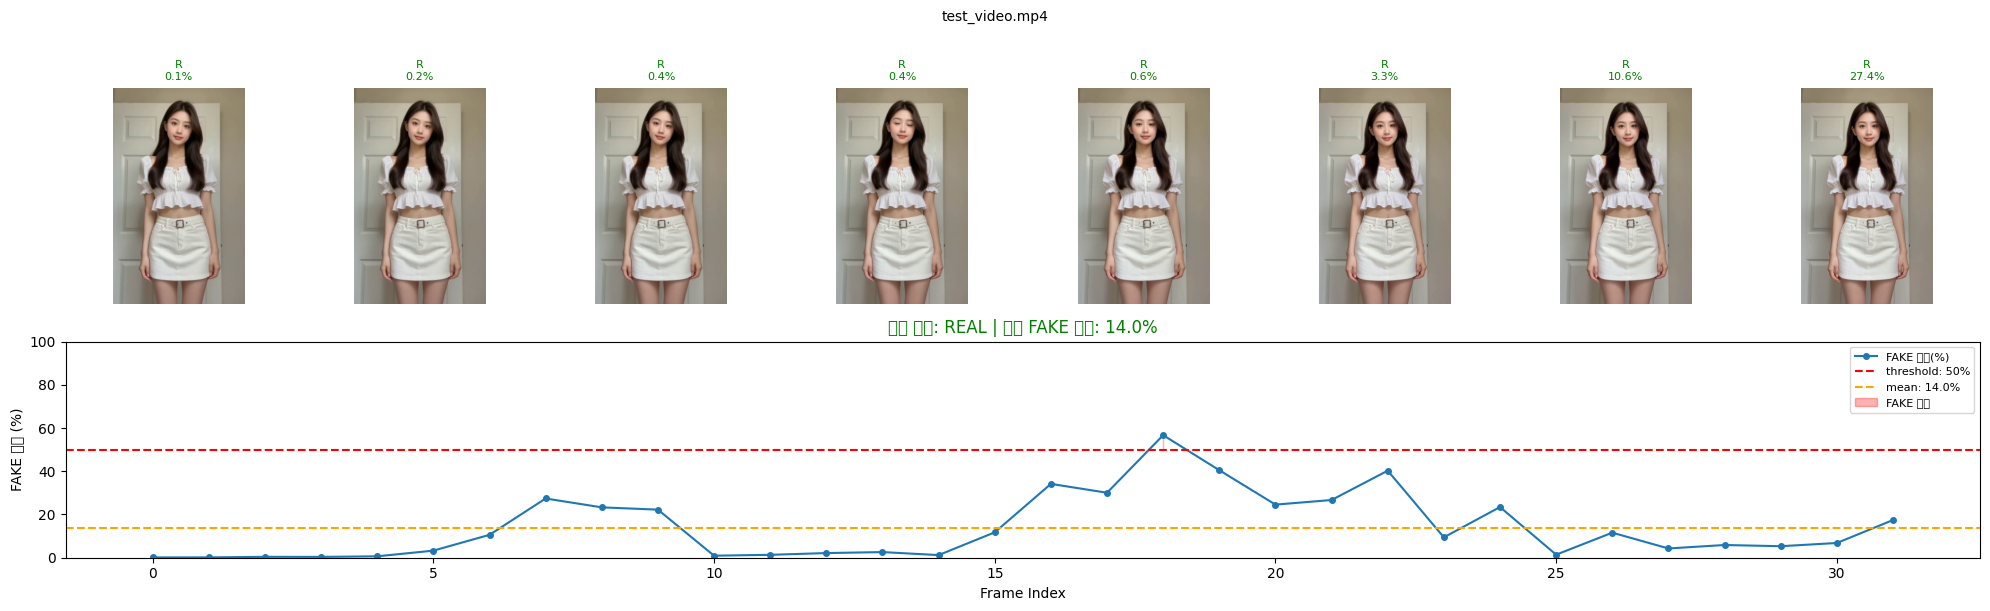

시각화 저장: C:\Users\user\Desktop\deepfake-detector\models\clip_lndf\inference_test_video.png


In [5]:
# ============================================================
# 셀 5 - 테스트 2: 최신 fake 영상 단건 테스트
# OCC 모델에서 REAL로 잘못 판별했던 영상을 테스트합니다.
# ============================================================

video_path = r"C:\Users\user\Desktop\deepfake-detector\test_samples\video\fake\test_video.mp4"  # 경로 수정
result = predict_video(video_path, sample_frames=32, visualize=True)